# Decoding repeated image trials with population normalization

This notebook loads the repeated-presentation raster data following `self_consistency_dev.ipynb`, selects a small image subset, and measures image decoding accuracy over time. Cross-validation is over repetitions: in each fold, one repetition of every selected image is held out and all remaining repetitions are used for training.

The preprocessing options let you remove population-vector information before decoding: L2 norm division, feature centering across samples as in `cosine_cnt`, and mean centering across features as in `correlation`.


In [11]:
import os
import sys
import yaml
from dataclasses import dataclass
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
if ENV not in config:
    raise KeyError(f"MY_ENV={ENV!r} is not in config.yaml. Available environments: {list(config)}")
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])

from useful_stuff.general_utils.utils import TimeSeries
from project_specific_utils.dataloader import decode_matlab_strings


In [38]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313to21"
    new_fs: int = 100
    n_images: int = 50
    min_repetitions: int = 4
    max_cv_folds: int | None = None  # set to an int to use fewer repetition folds
    random_state: int = None
    classifier: str = "nearest_centroid"  # "nearest_centroid", or "linear_svc" if sklearn is installed

cfg = Cfg()


## Load repeated trials

The next cell mirrors the explicit loading in `self_consistency_dev.ipynb`: `rasters` is converted to `(neurons, time, trials)`, image names are decoded from the MATLAB file, and the raster is resampled to `cfg.new_fs`.


In [39]:
rasters_path = f"{paths['data_path']}/data/rasters_{cfg.monkey_name}_{cfg.date}.mat"
with h5py.File(rasters_path, "r") as f:
    rasters = f["rasters"][:]

rasters = rasters[:, :300, :].T.astype(np.float32)  # neurons x time x trials, as in self_consistency_dev

allimgs_path = f"{paths['data_path']}/data/allimages_{cfg.monkey_name}_{cfg.date}.mat"
with h5py.File(allimgs_path, "r") as f:
    try:
        refs = f["allimages"][:]
    except KeyError:
        refs = f["uniqueImage"][:]
    monkey_presentation_order = decode_matlab_strings(f, refs)

monkey_presentation_order = np.asarray(monkey_presentation_order, dtype=object)
name_to_indices = {
    name: np.where(monkey_presentation_order == name)[0].tolist()
    for name in np.unique(monkey_presentation_order)
}

rasters_ts = TimeSeries(rasters, 1000)
rasters_ts.resample(cfg.new_fs)
rasters = rasters_ts.get_array().astype(np.float32)
fs = rasters_ts.get_fs()
time_s = np.arange(rasters.shape[1]) / fs

print("rasters:", rasters.shape, "neurons x time x trials")
print("images:", len(name_to_indices), "fs:", fs)
print("repetitions per image: min", min(map(len, name_to_indices.values())), "max", max(map(len, name_to_indices.values())))


rasters: (383, 30, 14840) neurons x time x trials
images: 776 fs: 100
repetitions per image: min 16 max 23


## Build a balanced repeated-trial subset

Each selected image contributes the same number of repetitions. The repetitions are shuffled within image, then fold `r` tests repetition `r` for every image and trains on the other repetitions.


In [40]:
def select_balanced_images(name_to_indices, n_images, min_repetitions=2, random_state=None, image_names=None):
    rng = np.random.default_rng(random_state)
    eligible = np.array([
        name for name, idx in name_to_indices.items()
        if len(idx) >= min_repetitions
    ], dtype=object)
    if len(eligible) == 0:
        raise ValueError(f"No images have at least {min_repetitions} repetitions.")

    if image_names is None:
        n_selected = min(n_images, len(eligible))
        selected = rng.choice(eligible, size=n_selected, replace=False).tolist()
    else:
        eligible_set = set(eligible)
        selected = [name for name in image_names if name in eligible_set]
        if not selected:
            raise ValueError("None of image_names are eligible with enough repetitions.")

    n_repetitions = min(len(name_to_indices[name]) for name in selected)
    return selected, n_repetitions


def make_repetition_tensor(rasters, name_to_indices, selected_names, n_repetitions=None, random_state=None):
    rng = np.random.default_rng(random_state)
    if n_repetitions is None:
        n_repetitions = min(len(name_to_indices[name]) for name in selected_names)

    image_trials = []
    selected_trial_indices = {}
    n_total_trials = rasters.shape[2]
    for name in selected_names:
        trial_idx = np.asarray(name_to_indices[name], dtype=int)
        if np.any((trial_idx < 0) | (trial_idx >= n_total_trials)):
            raise IndexError(f"Trial indices for {name!r} exceed raster trial axis length {n_total_trials}.")
        trial_idx = rng.permutation(trial_idx)[:n_repetitions]
        selected_trial_indices[name] = trial_idx.tolist()
        image_trials.append(rasters[:, :, trial_idx])

    # images x repetitions x neurons x time
    X = np.stack(image_trials, axis=0).transpose(0, 3, 1, 2)
    y = np.arange(len(selected_names))
    return X, y, selected_trial_indices


selected_names, n_repetitions = select_balanced_images(
    name_to_indices,
    n_images=cfg.n_images,
    min_repetitions=cfg.min_repetitions,
    random_state=cfg.random_state,
)
if cfg.max_cv_folds is not None:
    n_repetitions = min(n_repetitions, cfg.max_cv_folds)

X_rep, y_images, selected_trial_indices = make_repetition_tensor(
    rasters,
    name_to_indices,
    selected_names,
    n_repetitions=n_repetitions,
    random_state=cfg.random_state,
)

print("selected images:", len(selected_names))
print("repetitions used per image / CV folds:", n_repetitions)
print("X_rep:", X_rep.shape, "images x repetitions x neurons x time")


selected images: 50
repetitions used per image / CV folds: 17
X_rep: (50, 17, 383, 30) images x repetitions x neurons x time


## Preprocessing and classifiers

`feature_center` is fitted on the training samples only and applied to train/test. `mean_center` and `normalize` operate on each population vector independently. The order matches `preprocess_population_vectors` in `II_analyses.static_dyn`: feature center, mean center, then L2 normalize.


In [41]:
PREPROCESSING_CONFIGS = {
    "raw": dict(normalize=False, feature_center=False, mean_center=False),
    "norm": dict(normalize=True, feature_center=False, mean_center=False),
    "feature_center": dict(normalize=False, feature_center=True, mean_center=False),
    "feature_center_norm": dict(normalize=True, feature_center=True, mean_center=False),
    "mean_center": dict(normalize=False, feature_center=False, mean_center=True),
    "mean_center_norm": dict(normalize=True, feature_center=False, mean_center=True),
}


def fit_preprocess(X_train, *, normalize=False, feature_center=False, mean_center=False, eps=1e-12):
    params = {
        "normalize": normalize,
        "feature_center": feature_center,
        "mean_center": mean_center,
        "eps": eps,
        "feature_mean": None,
    }
    if feature_center:
        params["feature_mean"] = X_train.mean(axis=0, keepdims=True)
    return params


def transform_preprocess(X, params):
    X = np.asarray(X, dtype=float).copy()
    if params["feature_center"]:
        X -= params["feature_mean"]
    if params["mean_center"]:
        X -= X.mean(axis=1, keepdims=True)
    if params["normalize"]:
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        X /= np.maximum(norms, params["eps"])
    return X


def fit_nearest_centroid(X_train, y_train):
    classes = np.unique(y_train)
    centroids = np.stack([X_train[y_train == cls].mean(axis=0) for cls in classes], axis=0)
    return {"classes": classes, "centroids": centroids}


def predict_nearest_centroid(model, X_test):
    distances = ((X_test[:, None, :] - model["centroids"][None, :, :]) ** 2).sum(axis=2)
    return model["classes"][np.argmin(distances, axis=1)]


def fit_classifier(X_train, y_train, classifier="nearest_centroid"):
    if classifier == "nearest_centroid":
        return fit_nearest_centroid(X_train, y_train)
    if classifier == "linear_svc":
        from sklearn.svm import LinearSVC
        model = LinearSVC(C=1.0, dual="auto", max_iter=5000)
        model.fit(X_train, y_train)
        return model
    raise ValueError(f"Unknown classifier: {classifier}")


def predict_classifier(model, X_test, classifier="nearest_centroid"):
    if classifier == "nearest_centroid":
        return predict_nearest_centroid(model, X_test)
    if classifier == "linear_svc":
        return model.predict(X_test)
    raise ValueError(f"Unknown classifier: {classifier}")


## Cross-validate over repetitions


In [42]:
def crossvalidate_decoding_over_repetitions(
    X_rep,
    preprocessing,
    classifier="nearest_centroid",
    repetition_folds=None,
):
    """Decode image identity over time, leaving out one repetition per image per fold.

    Parameters
    ----------
    X_rep : ndarray
        Shape: images x repetitions x neurons x time.
    preprocessing : dict
        Flags for normalize, feature_center, and mean_center.
    classifier : str
        "nearest_centroid" or "linear_svc".
    repetition_folds : iterable[int] | None
        Which repetition indices to use as held-out folds.
    """
    n_images, n_repetitions, n_neurons, n_time = X_rep.shape
    labels_by_image = np.arange(n_images)
    if repetition_folds is None:
        repetition_folds = range(n_repetitions)

    fold_accuracies = []
    for held_out_rep in repetition_folds:
        train_reps = [rep for rep in range(n_repetitions) if rep != held_out_rep]
        X_train_all = X_rep[:, train_reps, :, :]  # images x train_reps x neurons x time
        X_test_all = X_rep[:, held_out_rep, :, :]  # images x neurons x time
        y_train = np.repeat(labels_by_image, len(train_reps))
        y_test = labels_by_image

        fold_time_accuracy = np.empty(n_time, dtype=float)
        for t in range(n_time):
            X_train_t = X_train_all[:, :, :, t].reshape(n_images * len(train_reps), n_neurons)
            X_test_t = X_test_all[:, :, t]

            params = fit_preprocess(X_train_t, **preprocessing)
            X_train_t = transform_preprocess(X_train_t, params)
            X_test_t = transform_preprocess(X_test_t, params)

            model = fit_classifier(X_train_t, y_train, classifier=classifier)
            y_pred = predict_classifier(model, X_test_t, classifier=classifier)
            fold_time_accuracy[t] = np.mean(y_pred == y_test)

        fold_accuracies.append(fold_time_accuracy)

    fold_accuracies = np.stack(fold_accuracies, axis=0)
    return {
        "fold_accuracies": fold_accuracies,
        "mean_accuracy": fold_accuracies.mean(axis=0),
        "std_accuracy": fold_accuracies.std(axis=0),
        "sem_accuracy": fold_accuracies.std(axis=0, ddof=1) / np.sqrt(fold_accuracies.shape[0])
        if fold_accuracies.shape[0] > 1 else np.zeros(fold_accuracies.shape[1]),
        "chance": 1 / n_images,
    }


In [43]:
results = {}
for label, preprocessing in PREPROCESSING_CONFIGS.items():
    print(f"running {label} ...")
    results[label] = crossvalidate_decoding_over_repetitions(
        X_rep,
        preprocessing=preprocessing,
        classifier=cfg.classifier,
    )

print("done")


running raw ...
running norm ...
running feature_center ...
running feature_center_norm ...
running mean_center ...
running mean_center_norm ...
done


## Accuracy over time


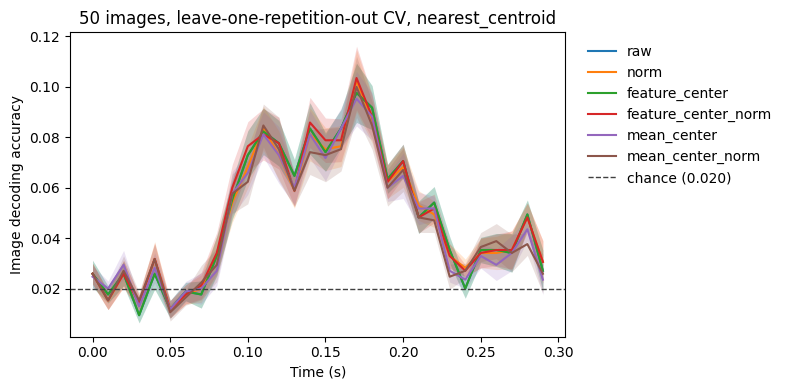

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, result in results.items():
    mean = result["mean_accuracy"]
    sem = result["sem_accuracy"]
    line, = ax.plot(time_s, mean, label=label)
    ax.fill_between(time_s, mean - sem, mean + sem, color=line.get_color(), alpha=0.18, linewidth=0)

chance = next(iter(results.values()))["chance"]
ax.axhline(chance, color="0.25", linestyle="--", linewidth=1, label=f"chance ({chance:.3f})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Image decoding accuracy")
ax.set_title(f"{cfg.n_images} images, leave-one-repetition-out CV, {cfg.classifier}")
#ax.set_ylim(0, 1)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


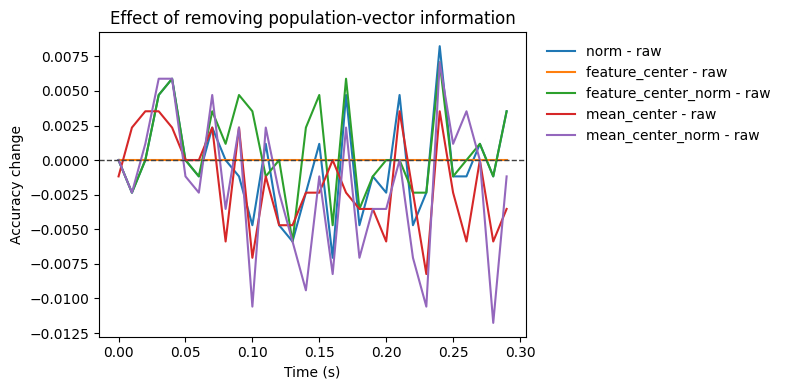

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
baseline = results["raw"]["mean_accuracy"]
for label, result in results.items():
    if label == "raw":
        continue
    ax.plot(time_s, result["mean_accuracy"] - baseline, label=f"{label} - raw")

ax.axhline(0, color="0.25", linestyle="--", linewidth=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy change")
ax.set_title("Effect of removing population-vector information")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## Fold-level diagnostics


In [46]:
summary = []
for label, result in results.items():
    peak_idx = int(np.argmax(result["mean_accuracy"]))
    summary.append((label, result["mean_accuracy"][peak_idx], time_s[peak_idx], result["mean_accuracy"].mean()))

for label, peak_acc, peak_time, mean_acc in summary:
    print(f"{label:20s} peak={peak_acc:.3f} at {peak_time:.3f}s | time-mean={mean_acc:.3f}")


raw                  peak=0.098 at 0.170s | time-mean=0.048
norm                 peak=0.102 at 0.170s | time-mean=0.048
feature_center       peak=0.098 at 0.170s | time-mean=0.048
feature_center_norm  peak=0.104 at 0.170s | time-mean=0.049
mean_center          peak=0.095 at 0.170s | time-mean=0.046
mean_center_norm     peak=0.100 at 0.170s | time-mean=0.046


## Notes for scaling up

Increase `cfg.n_images` after checking the 20-image run. If the full run is slow with `linear_svc`, keep `nearest_centroid` for the normalization comparison or reduce the number of folds with `cfg.max_cv_folds`.
